# KNN Regression Analysis

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
# Import clean dataset 
df_model = pd.read_csv("../data/housing_clean.csv")
print(f"Shape: {df_model.shape}")
df_model

Shape: (21612, 22)


,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month
0,7129300520,221900.0,3,1.00,1180,5650,1.0,0,0,3,...,0,1955,0,98178,47.5112,-122.257,1340,5650,2014,10
1,6414100192,538000.0,3,2.25,2570,7242,2.0,0,0,3,...,400,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12
2,5631500400,180000.0,2,1.00,770,10000,1.0,0,0,3,...,0,1933,0,98028,47.7379,-122.233,2720,8062,2015,2
3,2487200875,604000.0,4,3.00,1960,5000,1.0,0,0,5,...,910,1965,0,98136,47.5208,-122.393,1360,5000,2014,12
4,1954400510,510000.0,3,2.00,1680,8080,1.0,0,0,3,...,0,1987,0,98074,47.6168,-122.045,1800,7503,2015,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21607,263000018,360000.0,3,2.50,1530,1131,3.0,0,0,3,...,0,2009,0,98103,47.6993,-122.346,1530,1509,2014,5
21608,6600060120,400000.0,4,2.50,2310,5813,2.0,0,0,3,...,0,2014,0,98146,47.5107,-122.362,1830,7200,2015,2
21609,1523300141,402101.0,2,0.75,1020,1350,2.0,0,0,3,...,0,2009,0,98144,47.5944,-122.299,1020,2007,2014,6
21610,291310100,400000.0,3,2.50,1600,2388,2.0,0,0,3,...,0,2004,0,98027,47.5345,-122.069,1410,1287,2015,1


In [3]:
df_model.dtypes

id                 int64
price            float64
bedrooms           int64
bathrooms        float64
sqft_living        int64
sqft_lot           int64
floors           float64
waterfront         int64
view               int64
condition          int64
grade              int64
sqft_above         int64
sqft_basement      int64
yr_built           int64
yr_renovated       int64
zipcode            int64
lat              float64
long             float64
sqft_living15      int64
sqft_lot15         int64
sale_year          int64
sale_month         int64
dtype: object

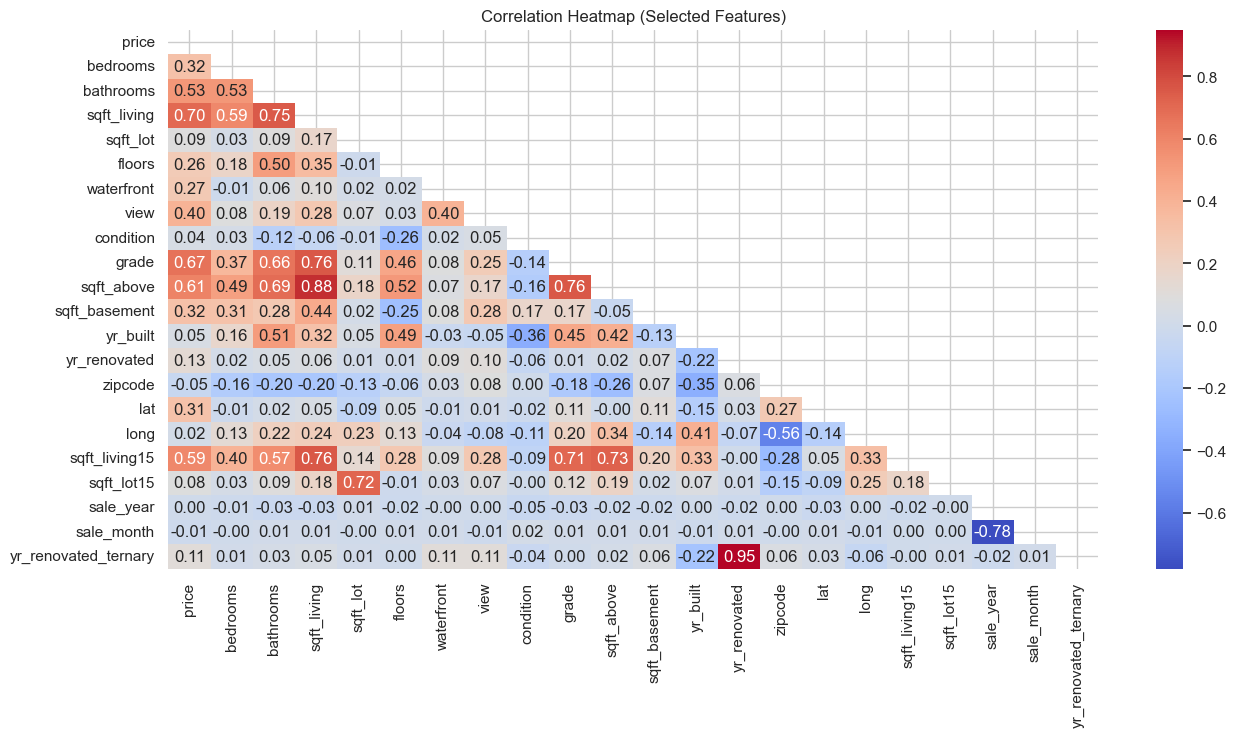

In [17]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [18]:
target_col = "price"
feature_cols = [c for c in df_model.columns if c != target_col]

X = df_model[feature_cols].copy()
X = X.drop('id', axis = 1)
y = df_model[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)


print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17289, 21)
X_test shape: (4323, 21)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,...,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_ternary
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,...,1955,0,98178,47.5112,-122.257,1340,5650,2014,10,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,...,1951,1991,98125,47.7210,-122.319,1690,7639,2014,12,2
2,2,1.00,770,10000,1.0,0,0,3,6,770,...,1933,0,98028,47.7379,-122.233,2720,8062,2015,2,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,...,1965,0,98136,47.5208,-122.393,1360,5000,2014,12,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,...,1987,0,98074,47.6168,-122.045,1800,7503,2015,2,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,...,2001,0,98053,47.6561,-122.005,4760,101930,2014,5,0
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,...,1995,0,98003,47.3097,-122.327,2238,6819,2014,6,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,...,1963,0,98198,47.4095,-122.315,1650,9711,2015,1,0
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,...,1960,0,98146,47.5123,-122.337,1780,8113,2015,4,0
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,...,2003,0,98038,47.3684,-122.031,2390,7570,2015,3,0


In [19]:
# Scale the data
scaler = StandardScaler()

# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

Base model, including all dataset but the id.

In [7]:
# Default hyperparameter: n_neighbors = 5
knn = KNeighborsRegressor()

# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.861
Testing set R-squared: 0.765
Training set RMSE: 135085.7
Testing set RMSE: 187861.0
Training set MAE: 74315.9
Testing set MAE: 98216.4


Remove features that have a correlation with price < 0.2 (results from the EDA)

In [20]:
# Keep only the features that have a correlation with price > 0.2 (results from EDA)
X2_train_scaled = X_train_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]
X2_test_scaled = X_test_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'floors', 'waterfront', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]

In [21]:
# Fit model
knn.fit(X2_train_scaled, y_train)

# Evaluate our fit model
y2_train_scaled_pred = knn.predict(X2_train_scaled)
y2_test_scaled_pred = knn.predict(X2_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y2_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y2_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y2_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y2_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y2_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y2_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.832
Testing set R-squared: 0.743
Training set RMSE: 148125.6
Testing set RMSE: 196446.5
Training set MAE: 82457.4
Testing set MAE: 104604.7


Results of both testing and training set worsened.

The next step is to remove features that have a correlation with price < 0.3 (results from the EDA)

In [22]:
# Keep only the features that have a correlation with price > 0.3 (results from EDA)
X3_train_scaled = X_train_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]
X3_test_scaled = X_test_scaled[['bedrooms', 'bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_basement', 'lat', 'sqft_living15']]

In [23]:
# Fit model
knn.fit(X3_train_scaled, y_train)

# Evaluate our fit model
y3_train_scaled_pred = knn.predict(X3_train_scaled)
y3_test_scaled_pred = knn.predict(X3_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y3_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y3_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y3_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y3_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y3_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y3_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.822
Testing set R-squared: 0.696
Training set RMSE: 152773.0
Testing set RMSE: 213450.5
Training set MAE: 84272.4
Testing set MAE: 108362.3


Results of both testing and training set worsened when compared with the previous 2 conditions.

The next step is to remove features that have a correlation with price < 0.5 (results from the EDA)

In [24]:
# Keep only the features that have a correlation with price > 0.5 (results from EDA)
X4_train_scaled = X_train_scaled[['bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_living15']]
X4_test_scaled = X_test_scaled[['bathrooms', 'sqft_living', 'view', 'grade', 'sqft_above', 'sqft_living15']]

In [25]:
# Fit model
knn.fit(X4_train_scaled, y_train)

# Evaluate our fit model
y4_train_scaled_pred = knn.predict(X4_train_scaled)
y4_test_scaled_pred = knn.predict(X4_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y4_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y4_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y4_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y4_test_scaled_pred, y_test)):.1f}') 

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y4_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y4_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.741
Testing set R-squared: 0.581
Training set RMSE: 184098.8
Testing set RMSE: 250766.8
Training set MAE: 120798.2
Testing set MAE: 157063.2


Again, the removal of more features negatively impacted the performance of the model.

Next, we'll transform the 'yr_renovated' into a ternary system, where non-renovated houses are kept as 0, houses renovated from 2000 onwards are transformed to 1, and houses renovated earliear than 2000 are transformed to 2.

In [26]:
df_model['yr_renovated'].value_counts()

yr_renovated
0       20698
2014       91
2013       37
2003       36
2005       35
        ...  
1951        1
1959        1
1948        1
1954        1
1944        1
Name: count, Length: 70, dtype: int64

In [27]:
# Group the 'yr-renovated' in different categories, where non-renovated houses are kept as 0
# houses renovated from 2000 onwards are transformed to 1
# houses renovated earliear than 2000 are transformed to 2
df_model["yr_renovated_ternary"] = np.select(
    [
        df_model['yr_renovated'].eq(0),
        df_model['yr_renovated'].between(2000, 2014, inclusive="both"),
    ],
    [
        0,
        1,
    ],
    default=2
)

df_model['yr_renovated_ternary'].value_counts().sort_index()

yr_renovated_ternary
0    20698
1      442
2      472
Name: count, dtype: int64

In [28]:
df_model.columns

Index(['id', 'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot',
       'floors', 'waterfront', 'view', 'condition', 'grade', 'sqft_above',
       'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
       'sqft_living15', 'sqft_lot15', 'sale_year', 'sale_month',
       'yr_renovated_ternary'],
      dtype='object')

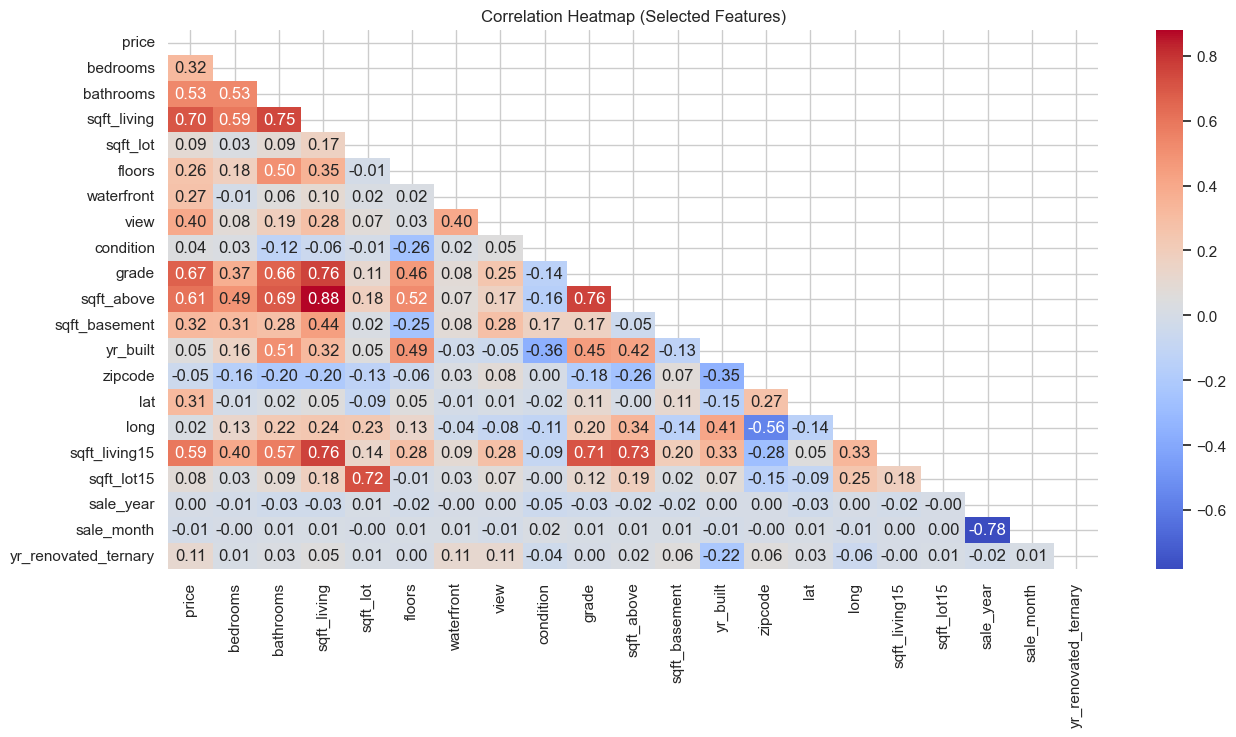

In [29]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id', 'yr_renovated'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [30]:
feature_cols = [c for c in df_model.columns if c != target_col]
X = df_model[feature_cols].copy()
X = X.drop(['id', 'yr_renovated'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17289, 20)
X_test shape: (4323, 20)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_ternary
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,1340,5650,2014,10,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1690,7639,2014,12,2
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,2720,8062,2015,2,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,1360,5000,2014,12,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,1800,7503,2015,2,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,98053,47.6561,-122.005,4760,101930,2014,5,0
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,98003,47.3097,-122.327,2238,6819,2014,6,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,98198,47.4095,-122.315,1650,9711,2015,1,0
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,98146,47.5123,-122.337,1780,8113,2015,4,0
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,98038,47.3684,-122.031,2390,7570,2015,3,0


In [31]:
# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [32]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.859
Testing set R-squared: 0.770
Training set RMSE: 135873.7
Testing set RMSE: 185634.6
Training set MAE: 74680.7
Testing set MAE: 97883.0


The ternary system slightly reduced the overfitting, increasing the testing R-squared.

Now test a binary system for 'yr_renovated' where 0 represents houses that were not renovated and 1 houses that were renovated.

In [33]:
# Binary classification of renovation, where 0 is not-renovated and 1 is renovated.
df_model["was_renovated"] = (df_model["yr_renovated"] > 0).astype(int)

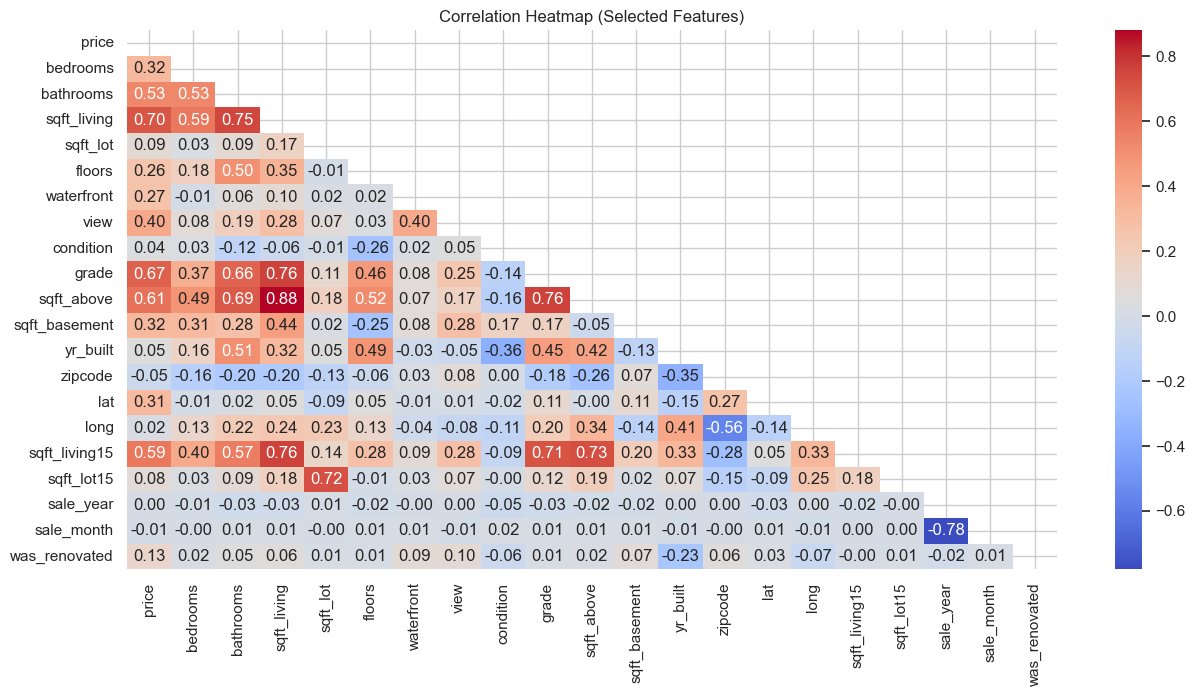

In [35]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id', 'yr_renovated', 'yr_renovated_ternary'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [36]:
feature_cols = [c for c in df_model.columns if c != target_col]
X = df_model[feature_cols].copy()
X = X.drop(['id', 'yr_renovated', 'yr_renovated_ternary'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17289, 20)
X_test shape: (4323, 20)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,yr_built,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,was_renovated
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,1955,98178,47.5112,-122.257,1340,5650,2014,10,0
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,1951,98125,47.7210,-122.319,1690,7639,2014,12,1
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,1933,98028,47.7379,-122.233,2720,8062,2015,2,0
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,1965,98136,47.5208,-122.393,1360,5000,2014,12,0
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,1987,98074,47.6168,-122.045,1800,7503,2015,2,0
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,2001,98053,47.6561,-122.005,4760,101930,2014,5,0
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,1995,98003,47.3097,-122.327,2238,6819,2014,6,0
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,1963,98198,47.4095,-122.315,1650,9711,2015,1,0
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,1960,98146,47.5123,-122.337,1780,8113,2015,4,0
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,2003,98038,47.3684,-122.031,2390,7570,2015,3,0


In [37]:
# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [38]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.861
Testing set R-squared: 0.765
Training set RMSE: 135085.7
Testing set RMSE: 187862.0
Training set MAE: 74315.9
Testing set MAE: 98221.9


The ternary system allows for a better model performance, with slightly less overfitting than the binary system.

Now, the 'yr_built' will be converted to house age.

In [39]:
df_model['age'] = df_model['sale_year'] - df_model['yr_built']

In [40]:
df_model['age'].value_counts()

age
 9      473
 8      443
 11     433
 0      430
 10     428
       ... 
 113     28
 115     26
 81      23
 80      21
-1       12
Name: count, Length: 117, dtype: int64

In [143]:
df_model[df_model['age'] < 0]

,id,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,...,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_ternary,was_renovated,age
1763,1832100030,597326.0,4,4.00,3570,8250,2.0,0,0,3,...,98040,47.5784,-122.226,2230,10000,2014,6,0,0,-1
2687,3076500830,385195.0,1,1.00,710,6000,1.5,0,0,3,...,98144,47.5756,-122.316,1440,4800,2014,10,0,0,-1
7526,9520900210,614285.0,5,2.75,2730,6401,2.0,0,0,3,...,98072,47.7685,-122.160,2520,6126,2014,12,0,0,-1
8039,1250200495,455000.0,2,1.50,1200,1259,2.0,0,0,3,...,98144,47.6001,-122.298,1320,1852,2014,6,0,0,-1
14489,2770601530,500000.0,2,2.25,1570,1269,2.0,0,0,3,...,98199,47.6514,-122.385,1570,6000,2014,8,0,0,-1
17097,9126100346,350000.0,3,2.00,1380,3600,3.0,0,0,3,...,98122,47.6074,-122.305,1480,3600,2014,6,0,0,-1
19804,9126100765,455000.0,3,1.75,1320,1014,3.0,0,0,3,...,98122,47.6047,-122.305,1380,1495,2014,8,0,0,-1
20769,9310300160,357000.0,5,2.50,2990,9240,2.0,0,0,3,...,98133,47.7384,-122.348,1970,18110,2014,8,0,0,-1
20851,1257201420,595000.0,4,3.25,3730,4560,2.0,0,0,3,...,98103,47.6725,-122.330,1800,4560,2014,7,0,0,-1
20962,6058600220,230000.0,3,1.50,1040,1264,2.0,0,0,3,...,98144,47.5951,-122.301,1350,3000,2014,7,0,0,-1


There are 12 entries where the age is negative, indicating the year of construction was higher than the year the house was sold. This could indicate the was was sold still under construction or is a data entry error. Hence, only rows with age <=0 will be considered.

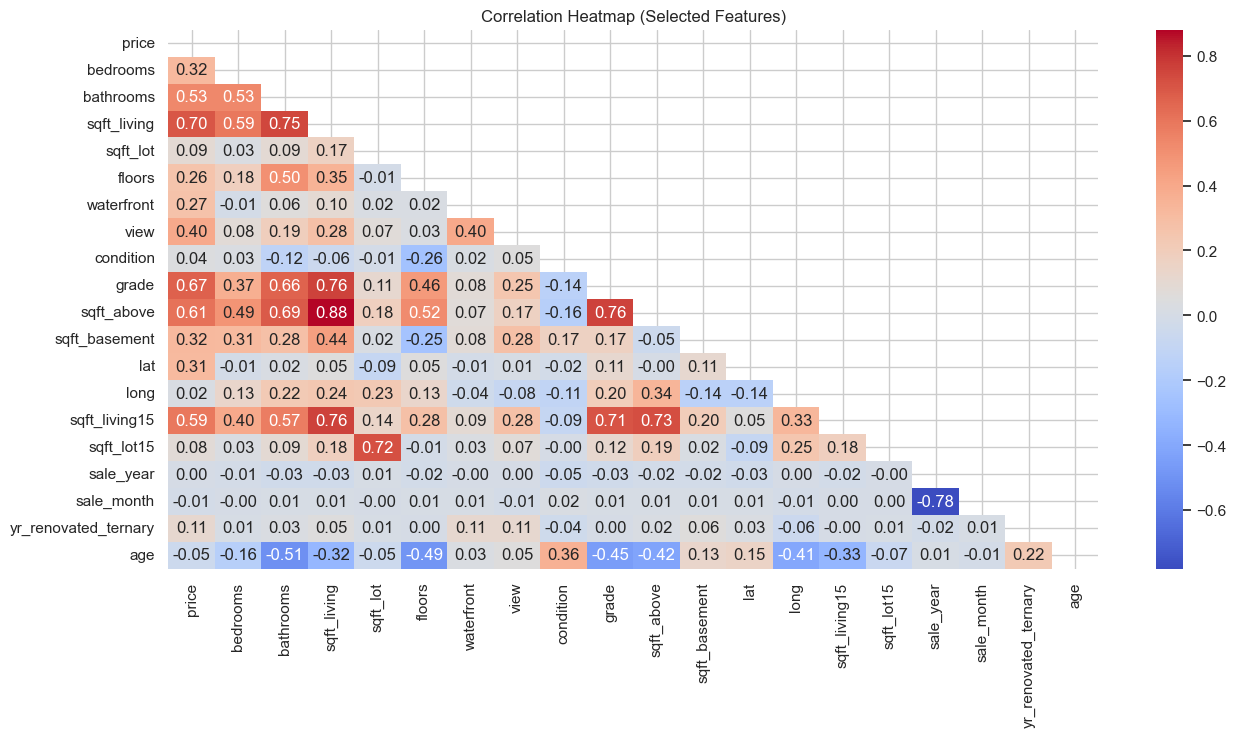

In [41]:
corr_cols = df_model.columns
corr_cols = corr_cols.drop(['id', 'zipcode', 'yr_renovated', 'was_renovated', 'yr_built'])

correlation_matrix = round(df_model[corr_cols].corr(),2)

mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
plt.figure(figsize=(15, 7))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap="coolwarm", fmt=".2f")

plt.title("Correlation Heatmap (Selected Features)")
plt.show()

In [42]:
feature_cols = [c for c in df_model.columns if c != target_col]
df_model_dropped_age = df_model[df_model['age']>=0]
y = df_model_dropped_age['price']
X = df_model_dropped_age[feature_cols].copy()
X = X.drop(['id', 'yr_renovated', 'was_renovated', 'yr_built'], axis = 1)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)
X.head(10)

X_train shape: (17280, 20)
X_test shape: (4320, 20)


,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_basement,zipcode,lat,long,sqft_living15,sqft_lot15,sale_year,sale_month,yr_renovated_ternary,age
0,3,1.00,1180,5650,1.0,0,0,3,7,1180,0,98178,47.5112,-122.257,1340,5650,2014,10,0,59
1,3,2.25,2570,7242,2.0,0,0,3,7,2170,400,98125,47.7210,-122.319,1690,7639,2014,12,2,63
2,2,1.00,770,10000,1.0,0,0,3,6,770,0,98028,47.7379,-122.233,2720,8062,2015,2,0,82
3,4,3.00,1960,5000,1.0,0,0,5,7,1050,910,98136,47.5208,-122.393,1360,5000,2014,12,0,49
4,3,2.00,1680,8080,1.0,0,0,3,8,1680,0,98074,47.6168,-122.045,1800,7503,2015,2,0,28
5,4,4.50,5420,101930,1.0,0,0,3,11,3890,1530,98053,47.6561,-122.005,4760,101930,2014,5,0,13
6,3,2.25,1715,6819,2.0,0,0,3,7,1715,0,98003,47.3097,-122.327,2238,6819,2014,6,0,19
7,3,1.50,1060,9711,1.0,0,0,3,7,1060,0,98198,47.4095,-122.315,1650,9711,2015,1,0,52
8,3,1.00,1780,7470,1.0,0,0,3,7,1050,730,98146,47.5123,-122.337,1780,8113,2015,4,0,55
9,3,2.50,1890,6560,2.0,0,0,3,7,1890,0,98038,47.3684,-122.031,2390,7570,2015,3,0,12


In [43]:
# Scale training set
X_train_scaled = scaler.fit_transform(X_train)
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)

# Scale testing set
X_test_scaled = scaler.transform(X_test)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

In [44]:
# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}')

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.850
Testing set R-squared: 0.771
Training set RMSE: 139849.0
Testing set RMSE: 186737.0
Training set MAE: 76546.3
Testing set MAE: 94051.9


In [73]:
grid = GridSearchCV(knn, 
                    {'n_neighbors': range(1,21)}, 
                    cv=5, 
                    scoring='neg_root_mean_squared_error')

grid.fit(X_train_scaled, y_train)

print(grid.best_params_)
print(grid.best_score_)

{'n_neighbors': 7}
-169738.0442601772


In [ ]:
# Define hyperparameter and change to manhattan distance
knn = KNeighborsRegressor(n_neighbors = 7, p=1)

# Fit model
knn.fit(X_train_scaled, y_train)

# Evaluate our fit model
y_train_scaled_pred = knn.predict(X_train_scaled)
y_test_scaled_pred = knn.predict(X_test_scaled)

# Calculate R-squared for training and testing sets
print(f'Training set R-squared: {r2_score(y_train, y_train_scaled_pred):.3f}')
print(f'Testing set R-squared: {r2_score(y_test, y_test_scaled_pred):.3f}')

# Calculate RMSE for training and testing sets 
print(f'Training set RMSE: {np.sqrt(mean_squared_error(y_train_scaled_pred, y_train)):.1f}')
print(f'Testing set RMSE: {np.sqrt(mean_squared_error(y_test_scaled_pred, y_test)):.1f}') #ou então RMSE

# Calculate MAE for training and testing sets
print(f'Training set MAE: {mean_absolute_error(y_train_scaled_pred, y_train):.1f}')
print(f'Testing set MAE: {mean_absolute_error(y_test_scaled_pred, y_test):.1f}')

Training set R-squared: 0.860
Testing set R-squared: 0.794
Training set RMSE: 135501.4
Testing set RMSE: 175687.1
Training set MAE: 73216.1
Testing set MAE: 90051.0
